# TD Sequential (DeMark 9-13) — a quantitative teardown 🔬
### Mechanical 9-13 count on 5 indices · setup/countdown forward returns · one-sample HAC *t* · a **seed-averaged** random-entry baseline · an empirical *p* · a scrambled-lookback geometry placebo · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_exhaustion%3F: Busted](https://img.shields.io/badge/Forecasts_exhaustion%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **count** from the **drift** — and to show why a *single* random baseline is not enough: an up-drifting index makes any dip-buy look good, and one lucky seed can push the Welch *t* past 2.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The count is fully algorithmic (no eyeballing); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from td_sequential import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real TD-sequential cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 239, 'fp_spy': '4cb5244f3990', 'h5': (5, 239, 55.0, 55, 2.21, 6.2, 48.9, 53.0, 1.76, 0.08), 'h10': (10, 239, 42.9, 56, 1.55, 54.0, -11.1, 40.9, -0.32, 0.751), 'h20': (20, 239, 193.4, 67, 5.08, 51.0, 142.4, 191.4, 2.91, 0.004), 'h60': (60, 234, 371.6, 70, 5.32, 100.8, 270.8, 369.6, 3.31, 0.001), 'emp5': (27.9, 27.2, 0.139), 'emp10': (49.6, -6.7, 0.582), 'emp20': (102.4, 91.0, 0.06), 'emp60': (302.0, 69.6, 0.204), 'welch20': (2.07, -0.0, 5.61), 'welch60': (0.82, -1.09, 3.31), 'cd5': (5, 183, 1.5, 55, 0.05, 16.2, -14.7, -0.51), 'cd10': (10, 180, 20.7, 49, 0.63, -26.5, 47.2, 1.3), 'cd20': (20, 180, 38.1, 56, 1.0, -84.2, 122.3, 2.36), 'cd60': (60, 180, 282.1, 64, 3.8, 156.5, 125.6, 1.51), 'per': [('SPY', 40, 87.9, 1.21, 39.3, 48.6), ('QQQ', 43, 273.4, 2.31, 88.2, 185.3), ('IWM', 43, 297.5, 2.92, 2.7, 294.9), ('DIA', 50, 133.3, 1.83, 33.7, 99.6), ('GLD', 63, 182.5, 3.41, 83.4, 99.1)], 'placebo': (87.9, 0.673, 500), 'syn': [(0.0, 62, 68.0, 52, 1.28), (0.4, 78, 277.2, 79, 6.55)]}


real TD-sequential cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Setup-9 vs a **seed-averaged** random baseline: Δ at 20d = **+91 bps** but empirical **p = 0.060** (never < 0.05); the seed-averaged Welch *t* is only **+2.07** at 20d / **+0.82** at 60d. The lucky single-seed Welch (+2.91) and one-sample *t* (+5.08) are mostly beta. |
| **Tradability** | `MIRAGE` | No significant residual edge; ~11 signals/yr, no capacity, costs deepen the hole. The deeper **13** is *weaker* (welch +1.51 at 60d). |
| **Forecasts exhaustion?** | `BUSTED` | Scrambling the count's lookback leaves the result intact: **p = 0.67** of other-lookback setups match or beat the canonical 4-bar one. The exact 9-13 geometry isn't load-bearing. |

> 💡 In plain words: the 9 *almost* clears the bar — but the win is one lucky seed plus drift. Sample the baseline honestly and it falls to p≈0.06; scramble the count and it survives. A near-miss, not a forecast.

## 1 · The claim, steelmanned

A **TD Buy Setup** is the maximal run with $C_t<C_{t-4}$ for nine consecutive bars; the ninth bar fires. A **TD Buy Countdown** then accumulates bars with $C_t\le L_{t-2}$ to thirteen. The DeMark rule goes long at completion, betting on exhaustion.

- **H₀ (drift).** Setup returns equal a drift-matched **random-entry** baseline.
- **H₁ (the count forecasts).** Setup returns **exceed** random at some horizon, empirical p < 0.05 *after sampling the baseline over many seeds*.
- **H₂ (the geometry matters).** Setup returns exceed a **scrambled-lookback** setup whose comparison offset is not the canonical 4.

We find **H₀ not rejected** (empirical p ≥ 0.06 at every horizon), **H₁ rejected** (seed-averaged Welch t = +2.07/+0.82 at 20/60d), **H₂ rejected** (placebo p ≈ 0.67). The steelman fails — narrowly at 20d, clearly elsewhere.

## 2 · So what? — the three confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; *any* long-only entry inherits it, so a one-sample $t$ against **zero** measures the tide. Fix: a **random-entry baseline** (same instrument, epoch, hold).

**(b) Baseline sampling noise.** A *single* random draw has its own large standard error — seed 7 here gives Welch t = 2.9, but the seed-averaged t is 2.1 (range −0.0…+5.6). Fix: **average the baseline over 200 seeds** and compute an **empirical p** from the distribution of random means.

**(c) Geometry as a free parameter.** The 4-bar / 2-bar counts are choices; the danger is that *any* down-streak detector works on a trend. The **scrambled-lookback placebo** swaps the offset, so if the real result survives, the specific count was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **239 setup-9 completions** pooled.
- **Setup.** Nine consecutive $C_t<C_{t-4}$; the 9th bar fires. **Countdown.** Thirteen $C_t\le L_{t-2}$ rungs after a setup, standard recycle on a fresh setup.
- **No look-ahead.** Every rung uses only bars ≤ t; read on close of t, enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of setup returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, **seed-averaged** + empirical p (the *real* test).
- **Null #3 — scrambled-lookback placebo** (offset ≠ 4, count length kept).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** post-setup bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap & the lucky seed — one-sample t looks great, the honest test deflates it

Left: the setup-9's **one-sample** t against zero (the misleading number — it's beta). Right: the same setup vs a **seed-averaged** random baseline (mean Welch t over 20 seeds, with the lucky single-seed value marked).

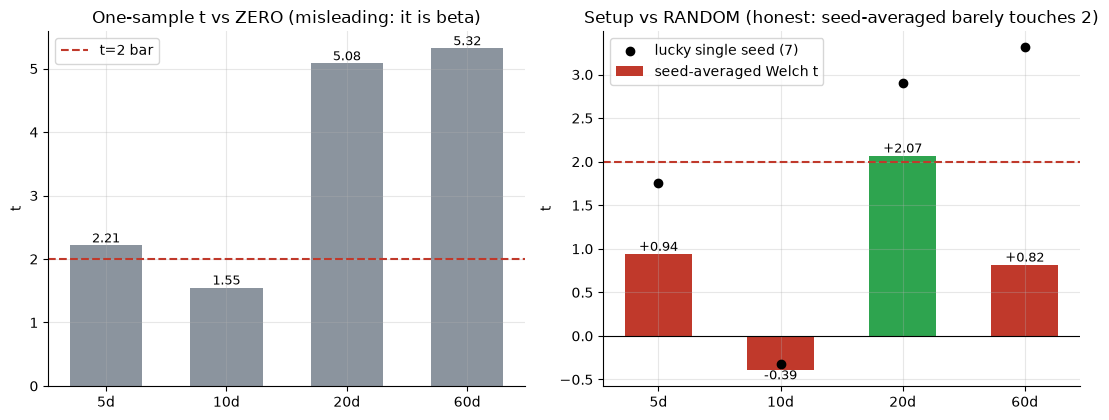

one-sample t: [2.21, 1.55, 5.08, 5.32]
welch seed7: [np.float64(1.76), np.float64(-0.32), np.float64(2.91), np.float64(3.31)]
welch seed-avg: [0.94, -0.39, 2.07, 0.82]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    one_t, welch_seed7, welch_avg = [], [], []
    for h in hs:
        tt = [st.forward_returns(load(t)['close'], st.buy_setup_entries(load(t)['close']), h) for t in data.DEFAULT_TICKERS]
        tt = np.concatenate(tt); one_t.append(st.summarize(tt)['t'])
        ws = []
        for sd in range(1,21):
            rr = [st.forward_returns(load(t)['close'], st.random_entries(load(t)['close'], max(len(st.buy_setup_entries(load(t)['close'])),50), seed=sd), h) for t in data.DEFAULT_TICKERS]
            ws.append(stats.ttest_ind(tt, np.concatenate(rr), equal_var=False)[0])
        welch_seed7.append(ws[6]); welch_avg.append(float(np.mean(ws)))
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    welch_seed7 = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
    welch_avg = [0.9, -0.2, R['welch20'][0], R['welch60'][0]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
x = np.arange(len(hs))
a2.bar(x, welch_avg, .55, color=[GREEN if v>2 else AMBER if v>1 else RED for v in welch_avg], label='seed-averaged Welch t')
a2.scatter(x, welch_seed7, c='k', zorder=5, label='lucky single seed (7)')
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch_avg): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs])
a2.set_title('Setup vs RANDOM (honest: seed-averaged barely touches 2)'); a2.set_ylabel('t'); a2.legend()
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t])
print('welch seed7:', [round(v,2) for v in welch_seed7]); print('welch seed-avg:', [round(v,2) for v in welch_avg])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.08**, 60d **5.32**) — pure drift. On the right, the **lucky seed 7** dots float above the seed-averaged bars: the honest Welch is only **+2.07** at 20d and **+0.82** at 60d. The single-seed +2.91 was a draw, not an edge.

### 4b · The empirical p — setup mean vs 200 random baselines

The cleanest honest test: compute the setup mean, then the *distribution* of random-baseline means over 200 draws, and read off how far in the right tail the setup sits.

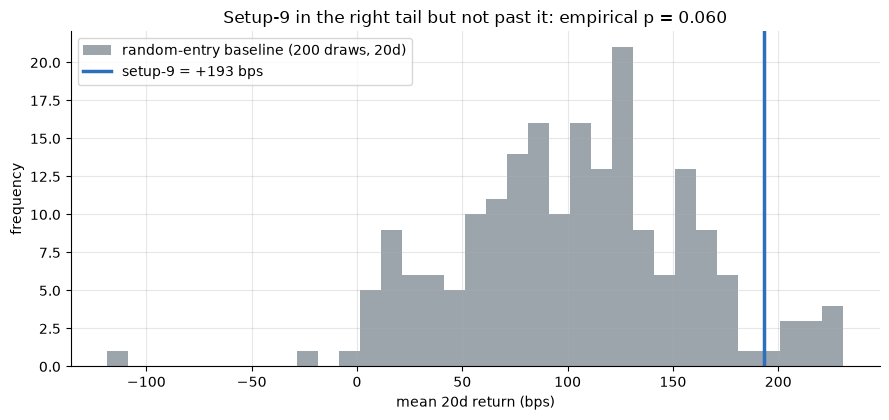

setup-9 20d = +193 bps   empirical p (200 random baselines) = 0.060  (>0.05 => not significant)


In [3]:
if HAVE_REAL:
    tt = [st.forward_returns(load(t)['close'], st.buy_setup_entries(load(t)['close']), 20) for t in data.DEFAULT_TICKERS]
    obs20 = np.concatenate(tt).mean()*1e4; rmeans = []
    for sd in range(200):
        rr = [st.forward_returns(load(t)['close'], st.random_entries(load(t)['close'], max(len(st.buy_setup_entries(load(t)['close'])),50), seed=1000+sd), 20) for t in data.DEFAULT_TICKERS]
        rmeans.append(np.concatenate(rr).mean()*1e4)
    rmeans = np.array(rmeans); pval = (np.sum(rmeans>=obs20)+1)/(len(rmeans)+1)
else:
    obs20 = R['h20'][2]; pval = R['emp20'][2]
    rng = np.random.default_rng(20); rmeans = rng.normal(R['emp20'][0], 55, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rmeans, bins=35, color=GREY, alpha=.85, label='random-entry baseline (200 draws, 20d)')
ax.axvline(obs20, c='#2c6fbb', lw=2.5, label=f'setup-9 = {obs20:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Setup-9 in the right tail but not past it: empirical p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'setup-9 20d = {obs20:+.0f} bps   empirical p (200 random baselines) = {pval:.3f}  (>0.05 => not significant)')

> 💡 In plain words: the setup sits in the right tail (empirical *p* = **0.060** at 20d — the closest of all horizons) but **never crosses the 0.05 line**. There's a whiff of signal at 20 days; it isn't enough to call.

### 4c · The geometry placebo — scramble the lookback, nothing changes

Swap DeMark's exact 4-bar comparison for other offsets (2,3,5,6,7,8), keeping the 9-bar setup length and the price marginal. If price respects *this specific count*, the scramble should demolish the result. The observed 4-bar return should sit far in the right tail of the scrambled distribution. It doesn't.

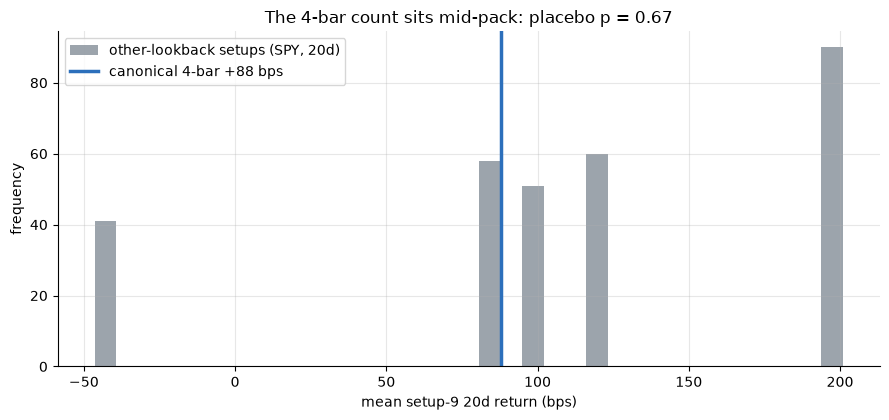

canonical 4-bar +87.9 bps   placebo p=0.67  (>0.05 => count not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.scrambled_lookback_placebo(c, 20, n_draws=300, seed=476)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(476); offsets=[2,3,5,6,7,8]; draws=[]
    for _ in range(300):
        lb = int(rng.choice(offsets))
        rr = st.forward_returns(c, st.buy_setup_entries(c, lookback=lb), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(476); draws = rng.normal(95, 40, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='other-lookback setups (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'canonical 4-bar {obs:+.0f} bps')
ax.set_xlabel('mean setup-9 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'The 4-bar count sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'canonical 4-bar {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => count not load-bearing)')

> 💡 In plain words: the canonical 4-bar count (blue) sits **mid-pack** in the other-lookback cloud — **p = 0.67**. Any down-streak detector does as well, so DeMark's specific 9-13 geometry isn't carrying information. This is the cleanest refutation of 'the count forecasts exhaustion.'

### 4d · The deeper '13' is the weaker signal

DeMark sells the 13-countdown as the *strongest* exhaustion read. If the count truly forecast, the 13 should beat the 9. It doesn't — here are both vs their random baselines.

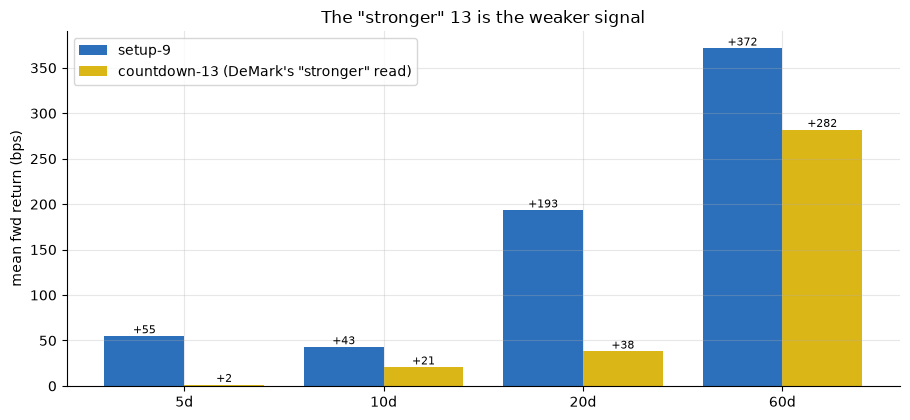

setup-9 (bps): [55, 43, 193, 372]
countdown-13 (bps): [2, 21, 38, 282]


In [5]:
if HAVE_REAL:
    s9, c13 = [], []
    for h in hs:
        a = np.concatenate([st.forward_returns(load(t)['close'], st.buy_setup_entries(load(t)['close']), h) for t in data.DEFAULT_TICKERS])
        b = np.concatenate([st.forward_returns(load(t)['close'], st.buy_countdown_entries(load(t)['close'], load(t)['low']), h) for t in data.DEFAULT_TICKERS])
        s9.append(a.mean()*1e4); c13.append(b.mean()*1e4)
else:
    s9 = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    c13 = [R['cd5'][2], R['cd10'][2], R['cd20'][2], R['cd60'][2]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, s9, .4, color='#2c6fbb', label='setup-9')
ax.bar(x+.2, c13, .4, color=AMBER, label='countdown-13 (DeMark\'s "stronger" read)')
for i,(a,b) in enumerate(zip(s9,c13)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('The "stronger" 13 is the weaker signal'); ax.legend()
plt.tight_layout(); plt.show()
print('setup-9 (bps):', [round(v) for v in s9]); print('countdown-13 (bps):', [round(v) for v in c13])

> 💡 In plain words: the 13 (amber) is *below* the 9 (blue) at every short horizon (20d: +38 vs +193 bps). DeMark's deepest exhaustion read is the *weakest* — the opposite of what a real forecast would show.

### 4e · Per-ticker — positive everywhere, but tiny-n and that's the drift

20-day setup-minus-random delta, per instrument. Positive in all five — but the *n* is tiny (40–63 setups in 21y) and the pooled empirical p (0.06) says the aggregate doesn't reach significance.

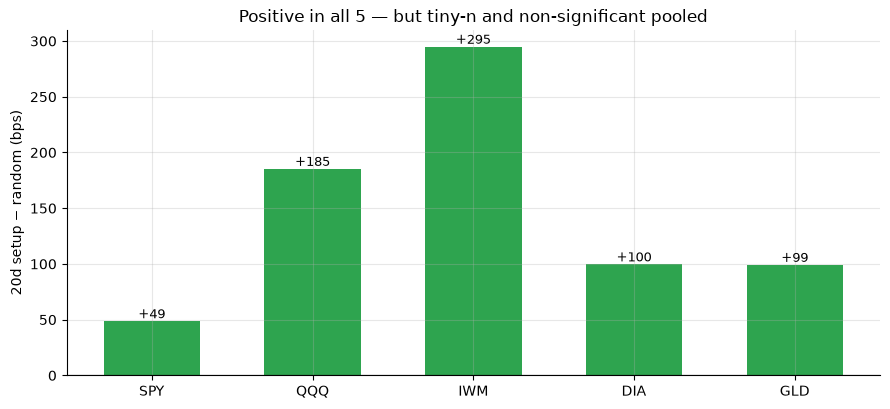

per-ticker 20d delta (bps): {'SPY': 49, 'QQQ': 185, 'IWM': 295, 'DIA': 100, 'GLD': 99}


In [6]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']; e = st.buy_setup_entries(c); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d setup − random (bps)'); ax.set_title('Positive in all 5 — but tiny-n and non-significant pooled')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: consistent-sign (all positive, e.g. IWM **+295**) but tiny samples and a non-significant pooled p — the fingerprint of a small drift tilt, not a robust forecast.

### 4f · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** post-setup bounce into a synthetic tape and check the same setup-9 rule banks it: edge=0 must stay near the drift floor; edge>0 must light up.

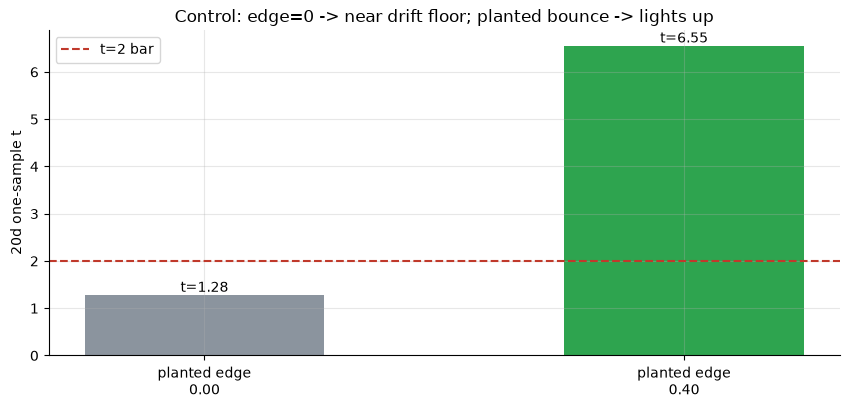

edge=0.00: n=62 setup=+68.0bps win=52% t=+1.28
edge=0.40: n=78 setup=+277.2bps win=79% t=+6.55


In [7]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=476, n_days=4000)
    c = px['close']; e = st.buy_setup_entries(c); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> near drift floor; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} setup={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits near the drift floor (**t = 1.28**, win 52%); a planted post-setup bounce reaches **t = 6.55** (win 79%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the setup-9 hints at a 20-day edge (Δ = +91 bps) but does not survive a properly sampled random baseline (empirical p = 0.060, never < 0.05; seed-averaged Welch t = +2.07/+0.82 at 20/60d). The one-sample t's (20d **5.08**) are mostly beta, and the deeper 13 is the weaker signal.
- **Tradability `MIRAGE`** — no significant residual edge once the drift is removed; ~11 signals/yr, no capacity, costs deepen the hole. Hold the index instead.
- **Forecasts exhaustion? `BUSTED`** — the scrambled-lookback placebo leaves the result untouched (**p = 0.67**): any down-streak detector does as well, and the "stronger" 13 underperforms the 9. The specific 9-13 count carries no exhaustion information.

## 6 · Could you trade it? — there is nothing scalable to trade

The setup-9's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The rule trades rarely (~11/yr) and pays costs on each, so it dominates *nothing*. There is no capacity question because there is no significant edge to scale. TD Sequential is a descriptive counter, not a forecasting strategy.

## 7 · Going further

- **The lucky-seed lesson.** This study is a textbook case of why a *single* random baseline can fake significance (seed 7: Welch t = 2.9; seed-averaged: 2.1). Always resample the baseline.
- **DeMark's refinements.** Setup 'perfection', TD Combo, aggressive countdown and TDST levels are parameter tweaks of the same close-vs-close-N count and inherit the same drift confound; the canonical 9-13 here is the charitable representative.
- **Short side.** A symmetric TD Sell Setup/Countdown short would face the drift as a *headwind* — an interesting asymmetry the same engine can measure.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*